# XX — Choosing the embedding dimension

This notebook investigates how large the embedding dimension `d` has to be to fit the student journey log, and
where more dimension stop buying anything.

For every `d` in `DIMENSIONS`, one block-structured model is trained on the log and its **total loss** is recorded. Each dimension is trained `RUNS` times from different initialisations, and reported as
**mean ± std** over those runs. Lower is a better fit. The dimension worth choosing is where
the curve flattens.

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import log_comparison_block as lcb

SEED = 42

# anchored on the notebook's own folder, so the paths hold whatever the cwd is
BASE_DIR = Path(lcb.__file__).resolve().parent

# the log to fit, and where the result goes
LOG_PATH = BASE_DIR / "data" / "preprocessed" / "students_filtered.csv"
OUT_DIR = BASE_DIR / "results"
OUT_PATH = OUT_DIR / "XX_dimensions.csv"
OUT_DIR.mkdir(parents=True, exist_ok=True)

assert LOG_PATH.exists(), f"log not found: {LOG_PATH}"

# architecture and training schedule parameters
C = 2  # context window, in semesters
UNIT_NORM = (
    True  # keep the course embeddings on the unit sphere, as the other notebooks
)
# do: every embedding is L2-normalised before the within-block sum, and the read-out is
# normalised too, so a course is described by its direction alone
LEARNING_RATE = 1e-2
EPOCHS = 1000
DEVICE = "cpu"

# the sweep
DIMENSIONS = [2, 4, 8, 16, 32, 64, 128]  # every d from 1 to 64
RUNS = 1

In [10]:
log = pd.read_csv(LOG_PATH)
traces = lcb._convert_to_blockEventLog(log)

In [11]:
rows = []
for d in tqdm(DIMENSIONS, desc="dimensions"):
    losses = []
    for r in range(RUNS):
        lcb.set_seed()
        _, loss = lcb._train_block(
            traces,
            C,
            d,
            LEARNING_RATE,
            EPOCHS,
            unit_norm=UNIT_NORM,
            device=DEVICE,
            verbose=True,
        )
        losses.append(loss)
    rows.append(
        {"dim": d, "loss": float(np.mean(losses)), "std": float(np.std(losses))}
    )

dimensions = pd.DataFrame(rows)
dimensions.to_csv(OUT_PATH, index=False)
print(f"results -> {OUT_PATH.name})")

dimensions:   0%|          | 0/7 [00:00<?, ?it/s]

Using device: cpu — 1000 epochs, lr=1.0e-02, unit norm


compass:   0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

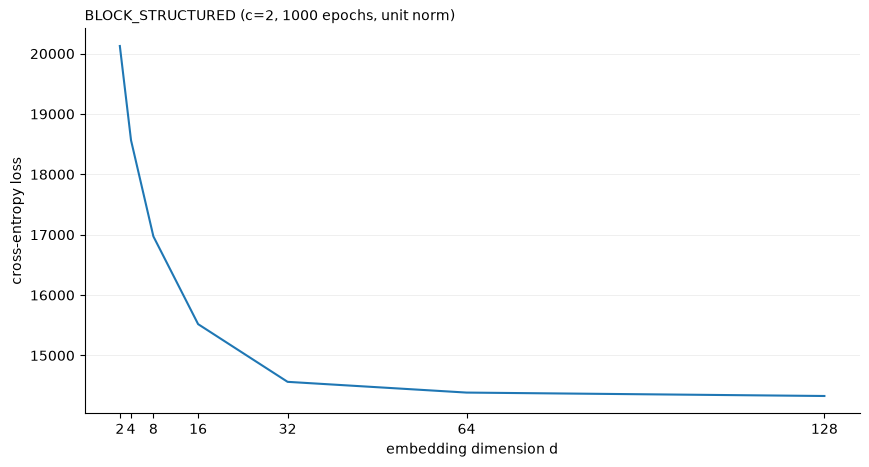

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_axisbelow(True)
ax.yaxis.grid(True, linewidth=0.4, alpha=0.35)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

ax.fill_between(
    dimensions["dim"],
    dimensions["loss"] - dimensions["std"],
    dimensions["loss"] + dimensions["std"],
    alpha=0.2,
    linewidth=0,
)
ax.plot(dimensions["dim"], dimensions["loss"], markersize=3)
ax.set_xticks(dimensions["dim"])
ax.set_xlabel("embedding dimension d")
ax.set_ylabel("cross-entropy loss")
ax.set_title(
    f"BLOCK_STRUCTURED (c={C}, {EPOCHS} epochs"
    + (", unit norm" if UNIT_NORM else "")
    + ")",
    loc="left",
    fontsize=10,
)
plt.show()